In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/rossmann-store-sales/sample_submission.csv
/kaggle/input/competitions/rossmann-store-sales/store.csv
/kaggle/input/competitions/rossmann-store-sales/train.csv
/kaggle/input/competitions/rossmann-store-sales/test.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/train.csv', low_memory=False)
store_df = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/store.csv')

df = pd.merge(train_df, store_df, on='Store', how='left')


print("(Rows, Columns):", df.shape)
df.head()

(Rows, Columns): (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
ds=train_df.copy

In [5]:
dz=store_df.copy

In [6]:
ds

<bound method NDFrame.copy of          Store  DayOfWeek        Date  Sales  Customers  Open  Promo  \
0            1          5  2015-07-31   5263        555     1      1   
1            2          5  2015-07-31   6064        625     1      1   
2            3          5  2015-07-31   8314        821     1      1   
3            4          5  2015-07-31  13995       1498     1      1   
4            5          5  2015-07-31   4822        559     1      1   
...        ...        ...         ...    ...        ...   ...    ...   
1017204   1111          2  2013-01-01      0          0     0      0   
1017205   1112          2  2013-01-01      0          0     0      0   
1017206   1113          2  2013-01-01      0          0     0      0   
1017207   1114          2  2013-01-01      0          0     0      0   
1017208   1115          2  2013-01-01      0          0     0      0   

        StateHoliday  SchoolHoliday  
0                  0              1  
1                  0         

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].max())

In [8]:
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales = monthly_sales.to_timestamp()

monthly_avg = monthly_sales.mean()

print("Monthly Average Sales:", monthly_avg)

Monthly Average Sales: 189457439.4516129


Text(0.5, 1.0, 'Promo on Sales')

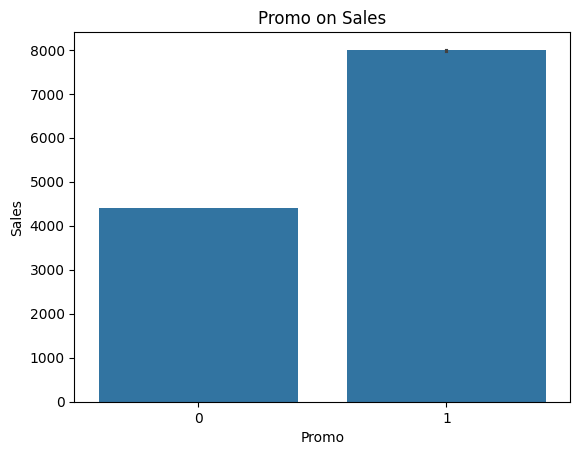

In [9]:
sns.barplot(x='Promo', y='Sales', data=df)
plt.title('Promo on Sales')

Text(0.5, 1.0, 'By Day of Week')

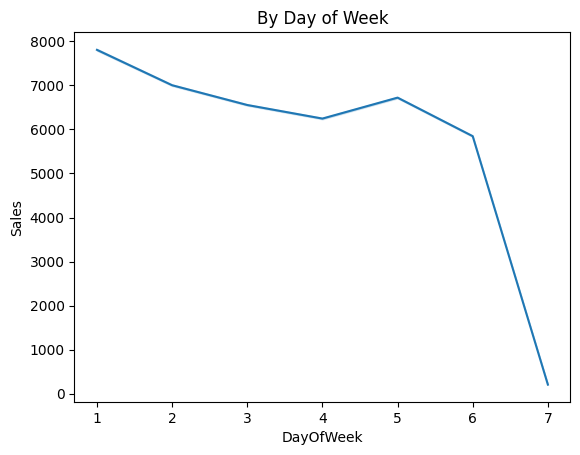

In [10]:
sns.lineplot(x='DayOfWeek', y='Sales', data=df)
plt.title('By Day of Week')

Text(0.5, 1.0, 'Sales Distribution by Store Type')

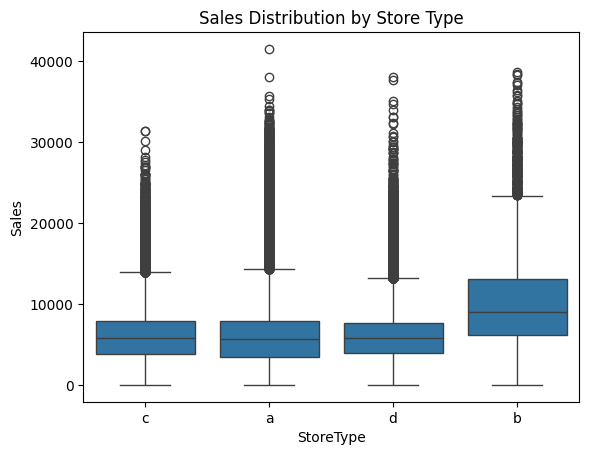

In [11]:
sns.boxplot(x='StoreType', y='Sales', data=df)
plt.title('Sales Distribution by Store Type')

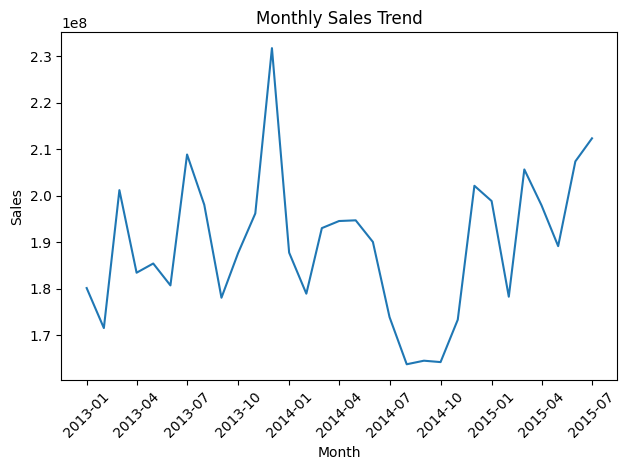

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

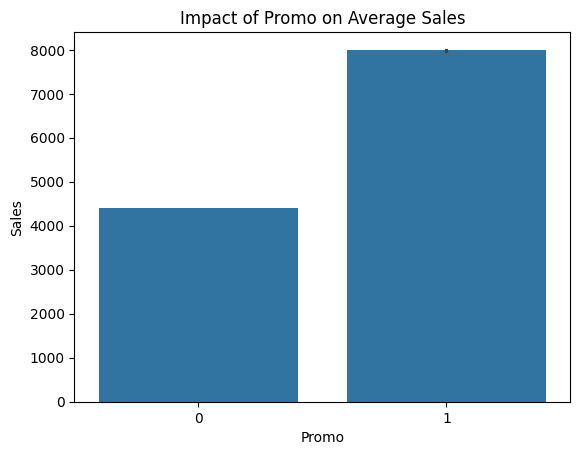

In [13]:
sns.barplot(x='Promo', y='Sales', data=df)
plt.title('Impact of Promo on Average Sales')
plt.show()

In [14]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

df['StoreType'] = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})
df['Assortment'] = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2})

df = df[df['Open'] != 0]

print("Features have been successfully installed!")
df.head()

Features have been successfully installed!


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,YearMonth,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,2008.0,0,NaN,NaN,NaN,2015-07,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015-07,2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015-07,2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,2009.0,0,NaN,NaN,NaN,2015-07,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,2015.0,0,NaN,NaN,NaN,2015-07,2015,7,31,31


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

#Feature Selection: Choosing relevant columns for the model
features = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 
            'StoreType', 'Assortment', 'CompetitionDistance', 'Month', 'Year', 'Day', 'WeekOfYear']

#Convert StateHoliday to numeric format to make it readable for the model
df['StateHoliday'] = df['StateHoliday'].astype(str).map({'0':0, 'a':1, 'b':2, 'c':3})

X = df[features]
y = df['Sales']

#Splitting the data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model Initialization: Using Random Forest Regressor
model = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)

print("Training started... This might take a moment due to the large dataset size.")
model.fit(X_train, y_train)

#Predictions and Evaluation: Using Mean Absolute Error (MAE)
y_pred = model.predict(X_test)
error = mean_absolute_error(y_test, y_pred)

print(f"Model Training Completed.")
print(f"Mean Absolute Error (MAE): {error:.2f} Euro")

Training started... This might take a moment due to the large dataset size.
Model Training Completed.
Mean Absolute Error (MAE): 636.77 Euro


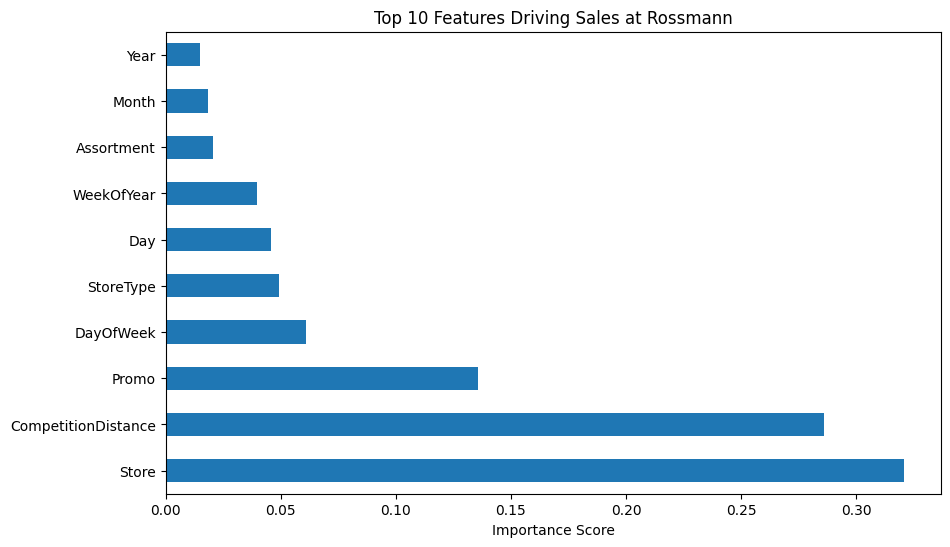

In [16]:
# Create a series to visualize which features impacted the sales most
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=features)
importances.nlargest(10).plot(kind='barh', figsize=(10, 6))

plt.title('Top 10 Features Driving Sales at Rossmann')
plt.xlabel('Importance Score')
plt.show()

In [17]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,YearMonth,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,2008.0,0,NaN,NaN,NaN,2015-07,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015-07,2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015-07,2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,2009.0,0,NaN,NaN,NaN,2015-07,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,2015.0,0,NaN,NaN,NaN,2015-07,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,1,1,1,...,2006.0,0,NaN,NaN,NaN,2013-01,2013,1,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,1,1,1,...,1999.0,0,NaN,NaN,NaN,2013-01,2013,1,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,1,1,1,...,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013-01,2013,1,1,1
1017042,948,2,2013-01-01,4491,1039,1,0,1,1,1,...,NaN,0,NaN,NaN,NaN,2013-01,2013,1,1,1
